In [5]:
# Import everything needed for building/running models and plotting

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import argparse
import markov_builder as mb
import scipy
import cma

from scipy.integrate import solve_ivp
from numba import njit
from markov_builder.example_models import construct_wang_chain
from markov_builder.example_models import construct_mazhari_chain
from markovmodels import MarkovModel
import myokit as mk

In [6]:
# Changes options here

args = {
        'model': 'Wang',
        'scaling_factor': 1.0,
        'default_parameters': {
            'b_a0_a': 0.047002, 
            'b_a0_b': 0.0631,
            'k_f_a': 0.023761,
            'k_b_a': 0.036778,
            'a_a0_a': 0.022348,
            'a_a0_b': 0.01176,
            'b_a1_a': 6.89e-05,
            'b_a1_b': 0.04178,
            'b_1_a': 0.006497,
            'b_1_b': 0.03268,
            'a_1_a': 0.090821,
            'a_1_b': 0.023391,
            'a_a1_a': 0.013733,
            'a_a1_b': 0.038198,
            'g_Kr': 0.1524, 'E_Kr': -88
        },
        'use_alternative_wang_parameters': True
}

Wang_param_dict = {
    'P0': 3.546036678184941e-02,
    'P1': 1.421035699521984e-01,
    'P2': 9.877327279605869e-02,
    'P3': 4.357013719775279e-02,
    'P4': 4.568654748807930e-02,
    'P6': 4.364219804435401e-03,
    'P8': 1.665047087946137e-02,
    'P9': 2.973302508538265e-03,
    'P10': 4.842049997526696e-06,
    'P11': 1.028380652171230e-02,
    'P12': 1.722202337234524e-02,
    'P13': 2.415760701638838e-02,
    'P14': 3.394689707316554e-03,
    'P15': 3.350175744025776e-02
}

param_translation_dict = {
    'P0': 'a_1_a',
    'P1': 'a_1_b',
    'P2': 'b_1_a',
    'P3': 'b_1_b',
    'P4': 'k_f_a',
    'P6': 'k_b_b',
    'P8': 'b_1_a',
    'P9': 'b_1_b',
    'P10': 'a_1_a',
    'P11': 'a_1_b',
    'P12': 'b_a0_a',
    'P13': 'b_a0_b',
    'P14': 'a_a0_a',
    'P15': 'a_a0_b'
}


In [7]:
# Setup staircase protocol
holding_potential = -80.0

# Use the simplified staircase protocol (no ramps)
mk_protocol = mk.load_protocol('simplified-staircase.mmt')
protocol = []
t_cur = 0
for event in mk_protocol.events():
    duration = event.duration()
    start_t = t_cur
    end_t = start_t + duration
    t_cur = end_t
    level = event.level()
    protocol.append((start_t, end_t, level, level))

protocol = np.vstack(protocol).astype(np.float64)

# Print out the protocol
print(protocol)

# Define a nice fast function for computing the voltage from the above array
@njit
def protocol_func(t, offset=0, protocol_description=protocol):
    t = t + offset
    if t < 0 or t >= protocol[-1][1]:
        return holding_potential

    for i in range(len(protocol)):
        if t <= protocol[i][1]:
            if np.abs(protocol[i][3] - protocol[i][2]) > 0.0:
                return protocol[i][2] + (t - protocol[i][0])*(protocol[i][3]-protocol[i][2])/(protocol[i][1] - protocol[i][0])
            else:
                return protocol[i][3]

[[    0.   250.   -80.   -80.]
 [  250.   300.  -120.  -120.]
 [  300.   700.  -120.  -120.]
 [  700.   900.   -80.   -80.]
 [  900.  1900.    40.    40.]
 [ 1900.  2400.  -120.  -120.]
 [ 2400.  3400.   -80.   -80.]
 [ 3400.  3900.   -40.   -40.]
 [ 3900.  4400.   -60.   -60.]
 [ 4400.  4900.   -20.   -20.]
 [ 4900.  5400.   -40.   -40.]
 [ 5400.  5900.     0.     0.]
 [ 5900.  6400.   -20.   -20.]
 [ 6400.  6900.    20.    20.]
 [ 6900.  7400.     0.     0.]
 [ 7400.  7900.    40.    40.]
 [ 7900.  8400.    20.    20.]
 [ 8400.  8900.    40.    40.]
 [ 8900.  9400.     0.     0.]
 [ 9400.  9900.    20.    20.]
 [ 9900. 10400.   -20.   -20.]
 [10400. 10900.     0.     0.]
 [10900. 11400.   -40.   -40.]
 [11400. 11900.   -20.   -20.]
 [11900. 12400.   -60.   -60.]
 [12400. 12900.   -40.   -40.]
 [12900. 13900.   -80.   -80.]
 [13900. 14400.    40.    40.]
 [14400. 14410.   -70.   -70.]
 [14410. 14510.   -70.   -70.]
 [14510. 14900.  -120.  -120.]
 [14900. 15400.   -80.   -80.]]


In [8]:
# Define functions for later use 
#

# Compute a 'reference solution' using a fine tolerance and the whole Q matrix (no removed states)
def get_reference_solution(mc, protocol, ts, voltage_func, tol=1e-12, scaling_factor=1.0,
                           default_parameters=None):
    # start with equal proportion of channels in each state
    state_labels, Q = mc.get_transition_matrix()
    y0 = np.full(Q.shape[0], 1.0)
    y0 = y0 / float(len(y0))

    y = sp.Matrix([mc.get_state_symbol(s)
                   for s in state_labels])
    parameter_labels = [key
                        for key, val in mc.default_values.items()
                        if str(key) not in ['E_Kr', 'E_rev', 'V'] and val is not None]
    v = sp.sympify('V')
    inputs = (y, parameter_labels, v)

    rhs_expr = (Q.T @ y).subs(mc.rate_expressions)
    rhs_func = njit(sp.lambdify(inputs, rhs_expr))
    Q_func = njit(sp.lambdify(inputs, Q.T.subs(mc.rate_expressions)))

    def jac_func(t, y, p):
        offset = p[-1]
        p = p[:-1].copy()
        v = voltage_func(t, offset=offset)
        return Q_func(y, p, v)
    
    def f_deriv(t, y, p):
        offset = p[-1]
        p = p[:-1].copy()
        v = voltage_func(t, offset=offset)
        return rhs_func(y.flatten(), p.flatten(), np.float64(v)).flatten()

    if default_parameters is None:
        default_parameters = mc.default_values()
    
    default_parameters_vec = np.array([val
                                   for key, val in mc.default_values.items()
                                   if (str(key) not in ['E_Kr', 'E_rev', 'V'] and val is not None)])

    default_parameters_vec *= scaling_factor
        
    # Add offset parameter
    p = np.append(default_parameters_vec, 0.0)
    res = []
    for step in protocol:
        tstart, tend, vstart, vend = step
        if tstart == tend:
            continue
    
        _ts = ts[(ts >= tstart) & (ts <= tend)]
    
        if tend not in _ts:
            _ts = np.append(_ts, tend)
    
        y = solve_ivp(f_deriv, (tstart, tend), y0, args=(p,), dense_output=True,
                      atol=tol, rtol=tol, method='BDF', jac=jac_func)
        _res = y.sol(_ts)
        y0 = _res[:, -1].flatten()
        res.append(_res[:, :-1])
    
    res.append(y0[:, None])
    res = np.hstack(res).T

    # Due to numerical errors we may have that x1 + x2 + ... + xN != 1
    # In which case we can simply normalise --- this has no effect on the dynamics of the system
    res = res / res.sum(axis=1)[:, None]
    return res


# Count the number of function evaluations (RHS of dx/dt = ... ) used to compute the ODE solution using the BDF method
# This gives some idea of how "hard" the system is to solve
# Lots of overlap and redudancy with the above function, so be careful!
def count_solver_steps(mm, protocol, ts, tol=1e-3, y0=None, use_Q=False, default_parameters=None,
                       scaling_factor=1.0):
    # start with equal proportion of channels in each state
    
    inputs = (mm.y, mm.p, mm.v)
    A_mat = mm.A.subs(mm.rates_dict)
    A_func = njit(sp.lambdify(inputs, mm.A.subs(mm.rates_dict)))
    
    Q_mat = mm.Q.subs(mm.rates_dict)
    Q_func = njit(sp.lambdify(inputs, mm.Q.subs(mm.rates_dict)))
    
    if y0 is None:
        y0 = np.full(len(mm.y), 1.0) / Q_mat.shape[0]
    
    if use_Q:
        rhs_func = njit(sp.lambdify(inputs, (mm.Q.T @ mm.y).subs(mm.rates_dict)))
    else:
        rhs_func = mm.get_rhs_func()
    
    voltage_func = mm.voltage

    def f_deriv(t, y, p):
        offset = p[-1]
        p = p[:-1].copy()
        v = voltage_func(t, offset=offset)
        return rhs_func(y, p, v).flatten()

    # Define jacobian function for ODE solver
    def jac_func(t, y, p=mm.default_parameters):
        offset = p[-1]
        p = p[:-1].copy()
        v = voltage_func(t, offset=offset)
        if use_Q:
            return Q_func(y, p, v)
        else:
            return A_func(y, p, v)

    if default_parameters is None:
        default_parameters = mm.get_default_parameters()

    default_parameters *= scaling_factor
    # Add offset parameter
    p = np.append(mm.get_default_parameters(), 0.0)
    
    count = 0
    res = []
    for step in protocol:
        tstart, tend, vstart, vend = step
        if tstart == tend:
            continue
        _ts = ts[(ts >= tstart) & (ts <= tend)]
    
        if tend not in _ts:
            _ts = np.append(_ts, tend)

        # We're using SciPy for ODE solving which is convinient but very slow compared to other methods
        # It shouldn't matter too much here though because we only need to solve ~100 times or so
        y = solve_ivp(f_deriv, (tstart, tend), y0, args=(p,), atol=tol,
                      rtol=tol, method='BDF', dense_output=True, jac=jac_func)
    
        y0 = y.y[:, -1].flatten()
        count += y.nfev
        res.append(y.sol(_ts[:-1]))
    
    res.append(y.sol(np.array([_ts[-1]])))
    res = np.hstack(res).T
    return count, res


# Construct a transformation matrix to eliminate vector v1 from the system. I.e [1, 0, 0, ..., 0] removes the first state 
def construct_transform_matrix(v1):
    v1 = v1 / np.linalg.norm(v1, 2)
    n = v1.shape[0]

    basis = np.full((n, n), 0.0)
    basis[0, :] = v1
    # basis[1, :] = np.full(n, 1/np.sqrt(n))
    # basis[0, :] = 0.0

    ones = np.eye(n)

    c = 1
    for i in range(n):
        if c >= n:
            break

        v = ones[i, :].flatten()
        for j in range(c):
            v -= np.dot(v, basis[j, :]) * basis[j, :]

        if np.linalg.norm(v, 2) > 1e-10:
            v /= np.linalg.norm(v, 2)
            basis[c, :] = v
            c += 1

    ret_val = basis.copy()
    ret_val[:-1, :] = basis[1:, :]
    ret_val[-1, :] = 1 / np.sqrt(n)
    return ret_val
    
# Rewrite dx/dt = Q.T x as dx/dt = Cx + d. Where C, d are obtained by eliminating vector e1 from Q 
def general_transform_with_reduction_vec(Q, e1):
    N = Q.shape[0]

    ortho_basis = construct_transform_matrix(e1)
    T = ortho_basis.copy()

    W = T @ Q.T @ np.linalg.inv(T)
    C = W[:-1, :-1]
    d = (1/np.sqrt(N)) * W[:-1, -1]

    return C, d

# Function to score the average condition number (over selection of voltages) under a given transformation
def opt_func(x, Q_func, voltages):
    x = x / np.sqrt(np.sum(x**2))

    score = 0

    conds = np.empty(len(voltages))

    T = construct_transform_matrix(x)

    norm_type = 2
    for i, v in enumerate(voltages):
        Q = Q_func(v).astype(np.float64)

        W = T @ Q.T @ np.linalg.inv(T)
        C = W[:-1, :-1]

        if not np.all(np.isfinite(C)):
            return np.inf

        conds[i] = np.linalg.cond(C, p=norm_type)

    return np.log10(np.mean(conds))


In [9]:
# Reverse parameter translation dict
param_translation_dict = {v: k for k, v in param_translation_dict.items()}

# Construct model using Markov builder
if args['model'] == 'Wang':
    mc = construct_wang_chain()
elif args['model']== 'Mazhari':
    mc = construct_mazhari_chain()
elif args['model'][:5] == 'model':
    model_no = int(args['model'][5:])
    from markov_builder.models.thirty_models import (
        model_00,
        model_01,
        model_02,
        model_03,
        model_04,
        model_05,
        model_06,
        model_07,
        model_08,
        model_09,
        model_10,
        model_11,
        model_12,
        model_13,
        model_14,
        model_20,
        model_30,
    )

    # Missing models here
    model_15 = None
    model_16 = None
    model_17 = None
    model_18 = None
    model_19 = None
    model_20 = None
    model_21 = None
    model_22 = None
    model_23 = None
    model_24 = None
    model_25 = None
    model_26 = None
    model_27 = None
    model_28 = None
    model_29 = None

    thirty_models = [
        model_00, model_01, model_02, model_03, model_04,
        model_05, model_06, model_07, model_08, model_09, model_10,
        model_11, model_12, model_13, model_14, model_15, model_16, model_17,
        model_18, model_19, model_20, model_21, model_22, model_23, model_24, model_25,
        model_26, model_27, model_28, model_29, model_30
    ]
    mc = thirty_models[model_no]()
# Code doesn't currently work with "disconnected models"
# It could be adapted by turning the models into connected models or 
# considering each component individually
if not mc.is_connected():
    raise NotImplementedError

print(mc.default_values)

if args['default_parameters']:
    default_parameters = args['default_parameters']
else:
    default_parameters = mc.default_values

if args['model'] == 'Wang' and args['use_alternative_wang_parameters']:
    default_parameters = {k: Wang_param_dict[param_translation_dict[k]]
                          if k in param_translation_dict else v
                          for k, v in default_parameters.items()}

print(default_parameters)
if args['default_parameters']:
    mc.default_values = default_parameters


{'b_a1_a': 6.89e-05, 'b_a1_b': 0.04178, 'a_1_a': 0.090821, 'a_1_b': 0.023391, 'a_a0_a': 0.022348, 'a_a0_b': 0.01176, 'b_a0_a': 0.047002, 'b_a0_b': 0.0631, 'b_1_a': 0.006497, 'b_1_b': 0.03268, 'a_a1_a': 0.013733, 'a_a1_b': 0.038198, 'k_f_a': 0.023761, 'k_b_a': 0.036778, 'V': None, 'g_Kr': 0.1524, 'E_Kr': -88}
{'b_a0_a': 0.01722202337234524, 'b_a0_b': 0.02415760701638838, 'k_f_a': 0.0456865474880793, 'k_b_a': 0.036778, 'a_a0_a': 0.003394689707316554, 'a_a0_b': 0.03350175744025776, 'b_a1_a': 6.89e-05, 'b_a1_b': 0.04178, 'b_1_a': 0.01665047087946137, 'b_1_b': 0.002973302508538265, 'a_1_a': 4.842049997526696e-06, 'a_1_b': 0.0102838065217123, 'a_a1_a': 0.013733, 'a_a1_b': 0.038198, 'g_Kr': 0.1524, 'E_Kr': -88}


In [10]:
# Set up some convinient variables for later use
states = mc.get_states()
parameter_labels = [key
                    for key, val in mc.default_values.items()
                    if str(key) not in ['E_Kr', 'E_rev', 'V'] and val is not None]
# Construct Q matrix
state_labels, Q = mc.get_transition_matrix(label_order=states)

# Define timesteps for protocol: time is in milliseconds. 1KHz sampling
tend = np.array(protocol)[-1, 1]
ts = np.linspace(0, int(tend), int(tend) + 1)

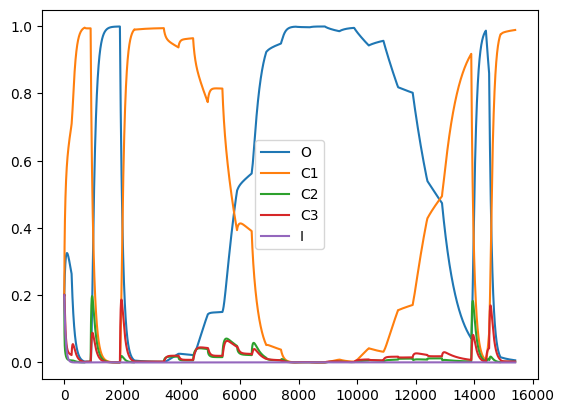

In [11]:
# Store and plot reference solution
tol = 1e-12

if args['model'] == 'Wang':
    tol = 1e-8

ref_res = get_reference_solution(mc, protocol, ts, protocol_func, tol=tol, scaling_factor=args['scaling_factor'],
                                 default_parameters=default_parameters)

plt.plot(ts, ref_res, label=states)
plt.legend()

In [12]:
# Try eliminating first state
eliminated_state = states[0]
labels = [s for s in states if s not in eliminated_state]
A, B = mc.eliminate_state_from_transition_matrix(labels,
                                                 use_parameters=True)
symbols = {}
symbols['v'] = sp.sympify('V')
symbols['p'] = sp.Matrix([sp.sympify(p) for p in parameter_labels])
symbols['y'] = sp.Matrix([mc.get_state_symbol(s)
                            for s in labels])
GKr_index = len(symbols['p']) - 1

default_parameters_vec = np.array([val
                               for key, val in mc.default_values.items()
                               if (str(key) not in ['E_Kr', 'E_rev', 'V'] and val is not None)])
    
mm = MarkovModel(symbols, A, B, mc.rate_expressions,
                 voltage=protocol_func,
                 default_parameters=default_parameters_vec,
                 Q=Q, name=mc.name,
                 parameter_labels=parameter_labels,
                 GKr_index=GKr_index,
                 E_rev=-80.0)
rates_func = mm.get_rates_func()

# Generate fast Q_func function
Q_func = njit(sp.lambdify((mm.rates_dict.keys(), mm.v), Q))

# Then we need a wrapper that only takes the voltage parameter (using default Markov-builder parameters)
sf = args['scaling_factor']
@njit
def _Q_func(v):
    rates = rates_func(default_parameters_vec * sf, v).flatten()
    return Q_func(rates, v)

voltages = np.unique(protocol[:, 2:])

# Try some random vectors, and pick one that gets a finite score
initial_score = np.nan
c = 0
while not np.isfinite(initial_score):
    x0 = np.full(Q.shape[0], 1.0)
    x0 = np.random.normal(0, 1, Q.shape[0])
    x0 = x0 / np.linalg.norm(x0, 2)
    initial_score = opt_func(x0, _Q_func, voltages)

# Run the optimization
sigma = 1.0
es = cma.CMAEvolutionStrategy(x0, sigma, {'maxiter': 1_000_000,
                                          'tolstagnation': 5000,
                                          'tolfacupx': 1_000_000_000,
                                          'popsize': 40,
                                          'tolfun': 1e-20,
                                          'tolflatfitness': 100})

_opt_func = lambda x: opt_func(x, _Q_func, voltages)

# This is a stochstic optimiser so the results are random.
# There's a small chance that it fails to find a good vector
es.optimize(_opt_func)
print(es.stop())

resvec = es.result.xbest
resvec /= np.linalg.norm(resvec, 2)

# Print the vector we found -- eliminating this vector from the system should lead
# to A matrices which are better conditioned (on average)
print(resvec)

# Compare above score with scores obtained by eliminating each state
# For the Wang model, we manage to score slightly better than by removing state C1,
# but not by very much!

for i, state in enumerate(states):
    vec = np.full(len(states), 0.0)
    vec[i] = 1.0
    score = opt_func(vec, _Q_func, voltages)
    print(f"Score when eliminating state {state} is {score:.2e}")

(20_w,40)-aCMA-ES (mu_w=11.3,w_1=16%) in dimension 5 (seed=924072, Tue May 20 16:03:11 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     40 2.232843420848502e+00 1.0e+00 1.18e+00  1e+00  1e+00 0:00.0
    2     80 2.235450989009924e+00 1.7e+00 1.06e+00  9e-01  1e+00 0:00.1
    3    120 2.189831127846920e+00 2.6e+00 1.14e+00  1e+00  1e+00 0:00.1
   78   3120 2.105006209831691e+00 2.3e+05 2.02e+07  2e+07  1e+09 0:02.8
{'tolfacupx': 1000000000}
[-0.80246036  0.47385987 -0.25602797 -0.25631791 -0.01627892]
Score when eliminating state O is 2.31e+00
Score when eliminating state C1 is 2.25e+00
Score when eliminating state C2 is 2.47e+00
Score when eliminating state C3 is 2.43e+00
Score when eliminating state I is 2.48e+00


In [13]:
# Generate another "MarkovModel" class with our transformed/reduced system using the optimised transformation
C, d = general_transform_with_reduction_vec(Q, resvec)
mm = MarkovModel(symbols, C, d, mc.rate_expressions,
                 voltage=protocol_func,
                 default_parameters=default_parameters_vec,
                 Q=Q, name=mc.name,
                 parameter_labels=parameter_labels,
                 GKr_index=GKr_index,
                 E_rev=-80.0)

ortho_basis = construct_transform_matrix(resvec)
N = Q.shape[0]
T = ortho_basis.copy()

# Check the condition of the T vector. Does this look sensible?
# The condition of the matrix should be too small, and the determinant of T shouldn't
# be too small/large
print(T, np.linalg.det(T), np.linalg.cond(T))

[[ 5.96705427e-01  6.37255409e-01 -3.44311092e-01 -3.44701003e-01
  -2.18921838e-02]
 [ 3.65354030e-16  6.07751898e-01  5.60648986e-01  5.61283886e-01
   3.56475029e-02]
 [-4.85180277e-16  3.13525933e-16  7.08217668e-01 -7.04574589e-01
  -4.47479882e-02]
 [-1.03803212e-14  6.98842582e-15 -7.88225224e-15  6.33829451e-02
  -9.97989280e-01]
 [ 4.47213595e-01  4.47213595e-01  4.47213595e-01  4.47213595e-01
   4.47213595e-01]] 0.3833628020400242 5.017695575603282


1e-08
1e-07
1e-06
1e-05
0.0001
0.001


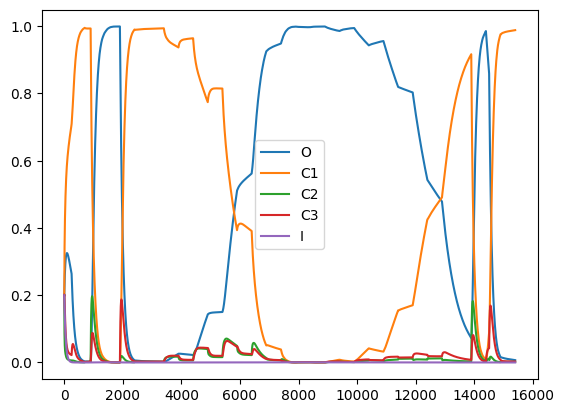

In [14]:
y0 = np.full(len(mm.get_state_labels()) + 1, 1.0)
y0 = y0 / (len(y0))
y0 = (T @ y0).flatten()[:-1]

# Vector of tolerances (atol==rtol) to explore
tols = 10.0**np.array(list(range(-8, -2)))

# Loop over tols and store RMSE (to ref solution) and total steps taken for "optimised" sytem 
rmse_vec = []
steps_taken_vec = []
for tol in tols:
    print(tol)
    count, ivp_res = count_solver_steps(mm, protocol, ts, tol=tol, y0=y0, default_parameters=default_parameters_vec,
                                       scaling_factor=args['scaling_factor'])
    steps_taken_vec.append(count)
    ivp_res = np.hstack([ivp_res, np.full((ivp_res.shape[0], 1), 1.0/np.sqrt(N))])
    ivp_res = np.linalg.solve(T, ivp_res.T).T
    rmse = np.sqrt(np.mean((ivp_res - ref_res)**2))
    rmse_vec.append(rmse)
    # Save some extra plots for debugging
    # plt.clf()
    # plt.plot(ts, ivp_res-ref_res)
    # plt.yscale('log')
    # plt.savefig("log_error_plot")

rmse_vec_opt = np.array(rmse_vec.copy())
steps_taken_vec_opt = np.array(steps_taken_vec)

# Plot example output of transformed system (transformed back into state occupancies
plt.clf()
plt.yscale('linear')
plt.plot(ts, ivp_res, label=states)
plt.legend()

In [15]:
# Do a big, ugly loop over all tolerances for each of the other transformations (removing each state).
# This may take a couple of minutes
rmses = []
steps_taken_vec = []
for tol in tols:
    for i, eliminated_state in enumerate(states):
        labels = [s for s in states if s not in eliminated_state]
        A, B = mc.eliminate_state_from_transition_matrix(labels,
                                                        use_parameters=True)

        GKr_index = len(parameter_labels) - 1

        symbols = {}
        symbols['v'] = sp.sympify('V')
        symbols['p'] = sp.Matrix([sp.sympify(p) for p in parameter_labels])
        symbols['y'] = sp.Matrix([mc.get_state_symbol(s)
                                  for s in labels])
        mm = MarkovModel(symbols, A, B, mc.rate_expressions,
                        voltage=protocol_func,
                        default_parameters=default_parameters_vec,
                        Q=Q, name=mc.name,
                        parameter_labels=parameter_labels,
                        GKr_index=GKr_index,
                        E_rev=-80.0)
        mm.protocol_description = protocol

        steps_taken, res = count_solver_steps(mm, protocol, ts, tol=tol,
                                              default_parameters=default_parameters_vec,
                                              scaling_factor=args['scaling_factor'])
        steps_taken_vec.append(steps_taken)

        missing_state_res = 1.0 - res.sum(axis=1).flatten()
        res = np.insert(res, i,
                        missing_state_res, axis=1)
        rmse = np.sqrt(np.mean((res - ref_res)**2))
        rmses.append(rmse)
        # plt.clf()
        # plt.plot(ts, res, label=labels + [eliminated_state])
        # plt.legend()
        # plt.savefig(f"{eliminated_state}_{tol:1e}_sol.pdf")

/home/pmzjs/code/irreducible_markov_models/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/bdf.py:415: RuntimeWarning: invalid value encountered in subtract
  D[order + 2] = d - D[order + 1]


In [16]:
# Now do the same for the "full" system -- solve using the Q.T matrix with no transformation.
# # Solving the whole system seems much less efficient for some reason, so this can take even longer
# # that before.
# rmses_full = []
# steps_taken_vec_full = []
# for tol in tols:
#     labels = states
#     A, B = mc.eliminate_state_from_transition_matrix(labels[:-1],
#                                                     use_parameters=True)

#     GKr_index = len(parameter_labels) - 1
#     default_parameters = np.array([val
#                                 for key, val in mc.default_values.items()
#                                 if (str(key) not in ['E_Kr', 'E_rev', 'V'] and val is not None)])
#     default_parameters *= args['scaling_factor']
#     symbols = {}
#     symbols['v'] = sp.sympify('V')
#     symbols['p'] = sp.Matrix([sp.sympify(p) for p in parameter_labels])
#     symbols['y'] = sp.Matrix([mc.get_state_symbol(s)
#                                 for s in labels])
#     mm = MarkovModel(symbols, A, B, mc.rate_expressions,
#                     voltage=protocol_func,
#                     default_parameters=default_parameters,
#                     Q=Q, name=mc.name,
#                     parameter_labels=parameter_labels,
#                     GKr_index=GKr_index,
#                     E_rev=-80.0)
#     mm.protocol_description = protocol

#     steps_taken, res = count_solver_steps(mm, protocol, ts, tol=tol, use_Q=True)
#     steps_taken_vec_full.append(steps_taken)

#     rmse = np.sqrt(np.mean((res - ref_res)**2))
#     rmses_full.append(rmse)

# steps_taken_vec = np.array(steps_taken_vec).reshape(len(tols), -1)
# rmses = np.array(rmses).reshape(len(tols), -1)

# rmses_all = np.hstack([rmses, rmse_vec_opt[:, None], np.array(rmses_full)[:, None]])
# steps_taken_vec_all = np.hstack([steps_taken_vec, steps_taken_vec_opt[:, None],
#                              np.array(steps_taken_vec_full)[:, None]])

# print(rmses, steps_taken_vec)

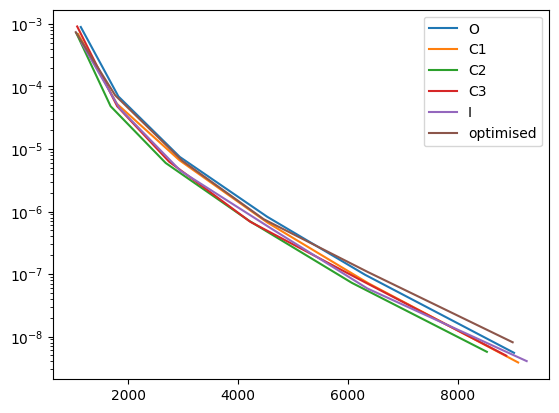

In [17]:
steps_taken_vec = np.array(steps_taken_vec).reshape(len(tols), -1)
rmses = np.array(rmses).reshape(len(tols), -1)

rmses_all = np.hstack([rmses, rmse_vec_opt[:, None]])
steps_taken_vec_all = np.hstack([steps_taken_vec, steps_taken_vec_opt[:, None]])


# Plot results
plt.clf()
labels = [s for s in states] + ['optimised']
plt.plot(steps_taken_vec_all, rmses_all, label=labels)
plt.yscale('log')
# plt.xscale('log')
plt.legend()

In [18]:
# # Repeat the above plot, but without the 'full' model results
# plt.clf()
# labels = [s for s in states] + ['optimised']


# rmses_all = np.hstack([rmses, rmse_vec_opt[:, None]])
# steps_taken_vec_all = np.hstack([steps_taken_vec, steps_taken_vec_opt[:, None]])


# # Remove "full" model values
# steps_taken_vec = steps_taken_vec[:, :-1]
# rmses = rmses[:, :-1]

# plt.plot(steps_taken_vec_all[:, :-1], rmses_all[:, :-1], label=labels)
# plt.yscale('log')
# plt.legend()